In [1]:
from IPython.display import HTML
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Montserrat:ital,wght@0,300;0,400;0,700;1,400&display=swap');
</style>
"""))

<h1 style="color:teal; font-size:45px; font-family:'Montserrat', sans-serif; font-weight:bold; margin-bottom: 5px;">
Notebook SENTINEL-2 - PIR Rio Tinto
</h1>

<p style="color:#444; font-size:12px; font-family:'Montserrat', sans-serif; border-bottom: 3px solid #2980b9; padding-bottom: 10px; font-weight:bold; margin-top: 0px;">
Data : EnMAP Image
</p>
<p style="font-size:16px; font-family:'Montserrat'; color:#34495e; margin-top: 0px; text-align: right;">
HOSSEINI Arman, STAUB Guillaume
</p>

<div style="margin-top: 30px;">
</div>
<div style="background-color: #ecf5fb; border-left: 15px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
<h2 style="color: teal; ">Index</h2>
<ul style="list-style-type: none; padding-left: 0;">
    <li style="margin-bottom: 8px;">
            <a href="#00" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">0.</span>
                <span style="color: #2c3e50; font-weight: 600;">Imports</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#10" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">1.</span>
                <span style="color: #2c3e50; font-weight: 600;">Visualization</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#20" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">2.</span>
                <span style="color: #2c3e50; font-weight: 600;">Direct K-Means</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#30" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">3.</span>
                <span style="color: #2c3e50; font-weight: 600;">Pixel-by-Pixel AutoEncoder with K-Means on latent-space</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#40" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">4.</span>
                <span style="color: #2c3e50; font-weight: 600;">2D Convolutional AutoEncoder with K-Means on latent space</span>
            </a>
        </li>
    <!--
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#21" style="color:#2c3e50; text-decoration: none;">2.1 </a></li>
    </ul>
    -->
</ul>
</div>
<div id="00"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    0. Imports
</h2>

In [43]:
import sys

import random

import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, adjusted_rand_score


import rasterio as rio
from rasterio.plot import reshape_as_image, reshape_as_raster

import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap

from kneed import KneeLocator

import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, Dataset, DataLoader, Subset

import xml.etree.ElementTree as ET

import re

from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster

<div id="10"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    1. Visualization

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We start by applying masks to the SENTINEL-2 image and display them.

In [3]:
def apply_mask(image_path, mask_path):
    # --- Image ---
    raster_img = rio.open(image_path)
    arr_img = reshape_as_image(raster_img.read())  # (m, n, l)

    # On ne met NaN que pour les pixels hors [0,1] (les zéros restent)
    mask_norm = np.all((arr_img >= 0) & (arr_img <= 1), axis=2)
    arr_img[~mask_norm] = np.nan

    image = reshape_as_raster(arr_img)
    l, m, n = image.shape

    X = image.reshape(l, -1).T
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # --- Masque ---
    with rio.open(mask_path) as src:
        mask_band = src.read(1)                 # (m, n)
    mask_soil = (mask_band > 0).astype(np.uint8)  # 1 = zone affichée, 0 = fond

    mask_soil_elargi = mask_soil[:, :, np.newaxis]          # (m, n, 1)
    vec_new = np.repeat(mask_soil_elargi, X_scaled.shape[1], axis=2)  # (m, n, l)

    X_scaled_soil = X_scaled.reshape(m, n, l) * vec_new

    # --- RGB ---
    RED   = X_scaled_soil[:, :, 2]
    GREEN = X_scaled_soil[:, :, 1]
    BLUE  = X_scaled_soil[:, :, 0]
    rgb = np.stack([RED, GREEN, BLUE], axis=-1)   # (m, n, 3)

    # --- Normalisation canal par canal ---
    min_val = np.nanmin(rgb, axis=(0, 1))
    max_val = np.nanmax(rgb, axis=(0, 1))
    scale = max_val - min_val
    scale[scale == 0] = 1
    rgb_norm = (rgb - min_val) / scale

    # --- FORCER le fond à noir ---
    # mask_soil == 0 -> fond, on les met à (0,0,0)
    fond = (mask_soil == 0)           # (m, n) bool
    rgb_norm[fond] = 0.0              # broadcasting sur la 3ème dimension

    plt.imshow(rgb_norm)
    plt.axis('off')
    plt.show()

    return rgb_norm, fond

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
SENTINEL-2 image with mask to only display the soil:

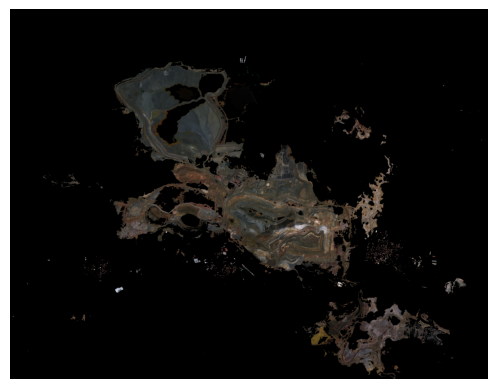

In [4]:
soil_only, fond_soil = apply_mask(r'./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_FRE_extrait_stack_gain_10m.img',
                       r"./mask_total_soil_VSWIR_10m.img")

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
EnMAP image with mask to only display the vegetation:

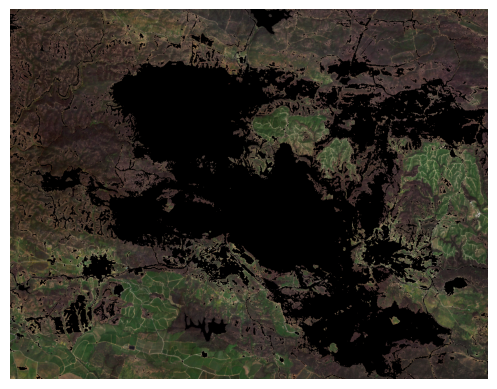

In [5]:
vegetation_only, fond_vegetation = apply_mask(r'./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_FRE_extrait_stack_gain_10m.img',
                             r"./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_mask_veg.img")

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We apply the vegetation mask and set all external pixels to the mean of the scaled vegetation pixel values:

In [6]:
image_path = r'./SENTINEL2B_20240410-112055-466_L2A_T29SQB_C_V3-1_FRE_extrait_stack_gain_10m.img'
raster_img = rio.open(image_path)
arr_img = reshape_as_image(raster_img.read())  # (m, n, l)
image = reshape_as_raster(arr_img)
l, m, n = image.shape

veg_mask_2d = (vegetation_only[:, :, 0] != 0)  # prendre la première bande uniquement
veg_mask_1d = veg_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
veg_pixels = pixels[veg_mask_1d]             # (N_veg, l) → uniquement végétation

scaler = StandardScaler()
X_scaled_veg = scaler.fit_transform(veg_pixels)
#print(X_scaled_veg.shape)
img_scaled_veg_complete = pixels.copy()
img_scaled_veg_complete[veg_mask_1d] = X_scaled_veg
img_scaled_veg_complete[~veg_mask_1d] = np.mean(X_scaled_veg)

<div id="20"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    2. Direct K-Means 

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We will use the knee criterion to guess the number of clusters we want for vegetation, soil and "other" separately:

<div id="21"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.1 Vegetation (and partial ARI)

In [7]:
def compute_optimal_k(X_scaled):

    inertias = []
    K_range = range(2, 20, 1)
    
    for k in K_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=3, random_state=42)
        kmeans.fit(X_scaled)
        inertias.append(kmeans.inertia_)
        #print("Done")
    
    plt.plot(K_range, inertias, marker='o')
    plt.xlabel('Number of clusters K')
    plt.ylabel('Inertia (Sum of distances)')
    plt.title('Knee criterion')
    plt.show()
    
    knee = KneeLocator(K_range, inertias, curve='convex', direction='decreasing')
    optimal_k = knee.knee
    
    print(f"optimal value: k = {optimal_k}")
    
    return optimal_k

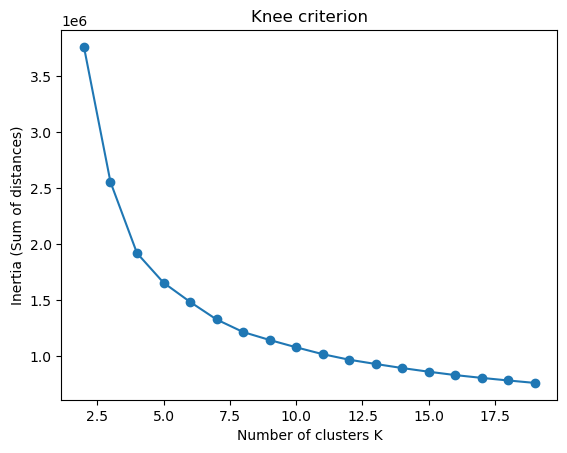

optimal value: k = 5


In [8]:
optimal_k_veg = compute_optimal_k(X_scaled_veg)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We apply K-Means and display the mean spectrum for each cluster. We also compute the Silhouette score as well as the Calinski-Harabasz Index.

In [9]:
def KMeans_mean_spectra(X_scaled, mask_1D, optimal_k, bands_number, max_samples=10000):
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42)
    labels = kmeans_final.fit_predict(X_scaled)
    
    n_samples = X_scaled.shape[0]
    
    if n_samples > max_samples:
        idx = np.random.choice(n_samples, max_samples, replace=False)
        X_sampled = X_scaled[idx]
        labels_sampled = labels[idx]
    else:
        X_sampled = X_scaled
        labels_sampled = labels
    
    sil_score = silhouette_score(X_sampled, labels_sampled)
    ch_score  = calinski_harabasz_score(X_scaled, labels)
    
    print(f"Silhouette (sampled) for k = {optimal_k} : {sil_score:.3f}")
    print(f"Calinski-Harabasz for k = {optimal_k} : {ch_score:.2f}")
    
    # Calcul des moyennes par cluster
    mean_spectra = np.zeros((optimal_k, bands_number))
    std_spectra = np.zeros((optimal_k, bands_number))
    
    for k in range(optimal_k):
        cluster_pixels = pixels[mask_1D][labels == k]
        mean_spectra[k] = cluster_pixels.mean(axis=0)
        std_spectra[k]  = cluster_pixels.std(axis=0)
    
    # Option : afficher sous forme de tableau avec pandas
    df_mean_spectra = pd.DataFrame(
        mean_spectra, 
        columns=[f'Bande_{i+1}' for i in range(bands_number)]
    )
    df_mean_spectra.index = [f'Cluster_{i+1}' for i in range(optimal_k)]
    
    plt.figure(figsize=(8,5))
    bands = np.array([492, 559, 664, 703, 739, 779, 832, 864, 1610,  2185])
    
    for k in range(optimal_k):
        plt.plot(bands, mean_spectra[k], label=f'Cluster {k+1}')
        plt.fill_between(
            bands,
            mean_spectra[k] - std_spectra[k],
            mean_spectra[k] + std_spectra[k],
            alpha=0.2
        )
    plt.xlabel('Wavelength')
    plt.ylabel('Average value')
    plt.title('Mean spectrum by cluster')
    plt.legend()
    plt.show()
    return labels

Silhouette (sampled) for k = 5 : 0.320
Calinski-Harabasz for k = 5 : 507206.16


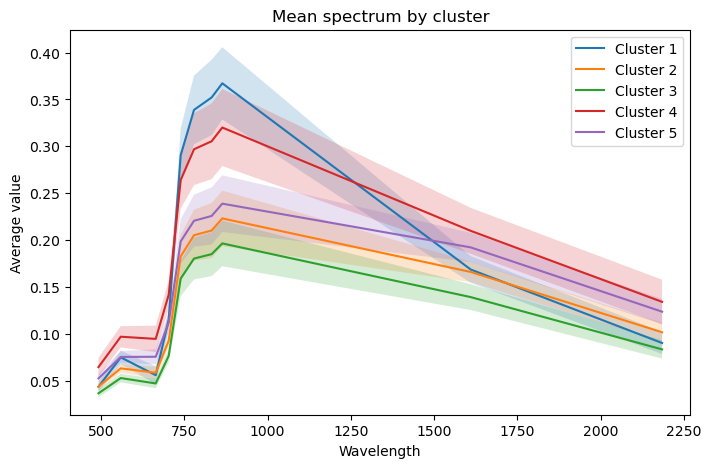

In [10]:
labels_veg = KMeans_mean_spectra(X_scaled_veg, veg_mask_1d, optimal_k_veg, l)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
Then, We can display the map with clustered vegetation. Masked pixels are displayed in black.

In [11]:
def display_clusters(mask_2D, labels, optimal_k):
    # --- 7) Construction de la carte finale ---
    cluster_map = np.zeros((m, n), dtype=int)
    cluster_map[mask_2D] = labels + 1  # 0 = fond, clusters à partir de 1
    
    # --- 8) Création de la colormap ---
    cmap_colors = ["black"] + list(plt.cm.tab10.colors[:optimal_k])
    cmap = colors.ListedColormap(cmap_colors)
    
    # --- 9) Affichage ---
    plt.figure(figsize=(10,10))
    plt.imshow(cluster_map, cmap=cmap)
    plt.axis('off')
    #plt.title("Clusters of vegetation")
    plt.show()

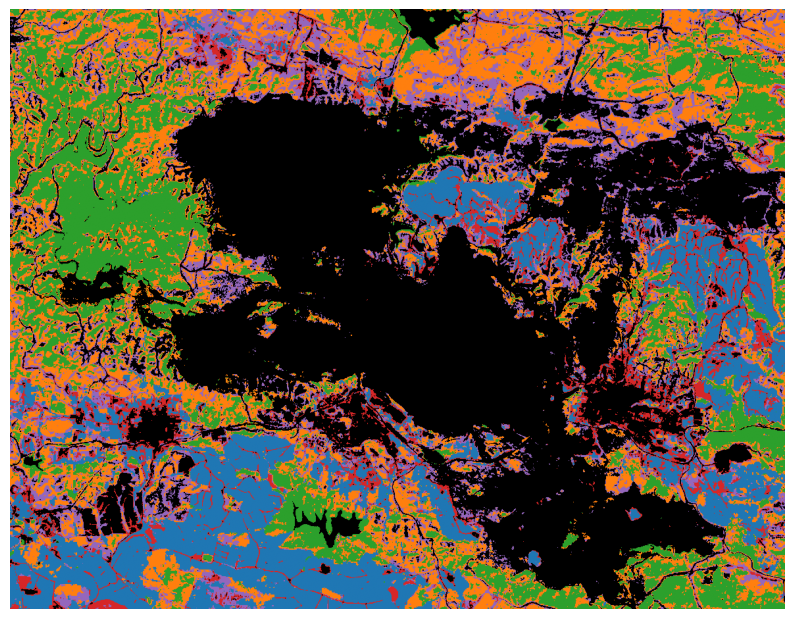

In [12]:
display_clusters(veg_mask_2d, labels_veg, optimal_k_veg)

In [13]:
# Chemins de fichiers (à adapter)
path_ground_truth = 'CS3_HandMadeSAM_lbl.img'

# 1. Lecture de la ground truth
with rio.open(path_ground_truth) as src_gt:
    ground_truth_array = src_gt.read(1)  # Lire la première (et unique) bande

# 2. Création du masque
# 'valid_pixels_mask' est VRAI là où il y a une étiquette de classe valide (> 0)
valid_pixels_mask = ground_truth_array > 0

# ground_truth_labels contient maintenant uniquement les étiquettes valides pour la comparaison
ground_truth_labels = ground_truth_array[valid_pixels_mask]

X_cluster = np.zeros((m,n))
X_cluster[veg_mask_2d] = labels_veg

# 4. Extraction des résultats de clustering pour les pixels valides
# On applique le même masque au résultat du clustering
cluster_labels_for_comparison = X_cluster[valid_pixels_mask]

# Calcul de l'Adjusted Rand Index
ari_score = adjusted_rand_score(
    labels_true=ground_truth_labels, 
    labels_pred=cluster_labels_for_comparison
)

print(f"The partial Adjusted Rand Index (ARI) on vegetation with Direct K-means is : {ari_score:.4f}")

The partial Adjusted Rand Index (ARI) on vegetation with Direct K-means is : 0.5077


<div id="22"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.2 Soil

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We compute the 1D and 2D masks for the soil.

In [14]:
soil_mask_2d = (soil_only[:, :, 0] != 0)  # prendre la première bande uniquement
soil_mask_1d = soil_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = image.reshape(l, -1).T   
soil_pixels = pixels[soil_mask_1d]     

scaler = StandardScaler()
X_scaled_soil = scaler.fit_transform(soil_pixels)

img_scaled_soil_complete = pixels.copy()
img_scaled_soil_complete[soil_mask_1d] = X_scaled_soil
img_scaled_soil_complete[~soil_mask_1d] = np.mean(X_scaled_soil)


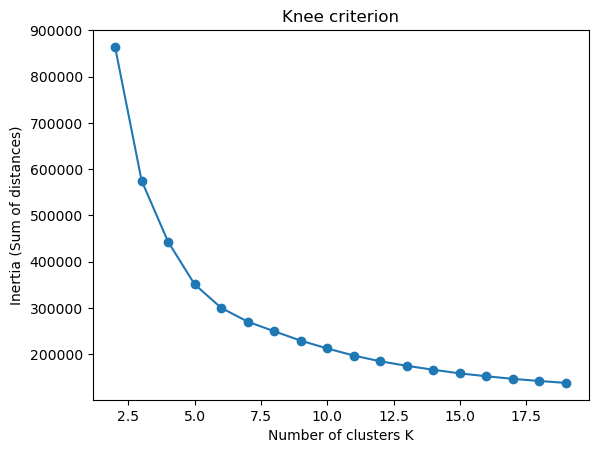

optimal value: k = 6


In [15]:
optimal_k_soil = compute_optimal_k(X_scaled_soil)

<div style="background-color: #f6bcb2; border-left: 5px solid #ff0000; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: 2d3436;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We decide to not use the optimal k for soil due to external knowledge, using k = 30 instead. 

In [16]:
optimal_k_soil = 30

Silhouette (sampled) for k = 30 : 0.210
Calinski-Harabasz for k = 30 : 88485.47


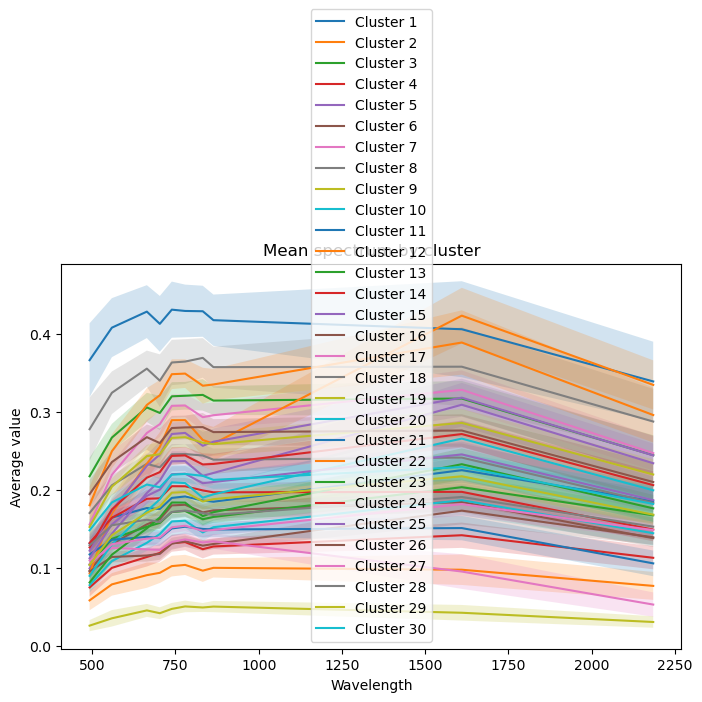

In [17]:
labels_soil = KMeans_mean_spectra(X_scaled_soil, soil_mask_1d, optimal_k_soil, l)

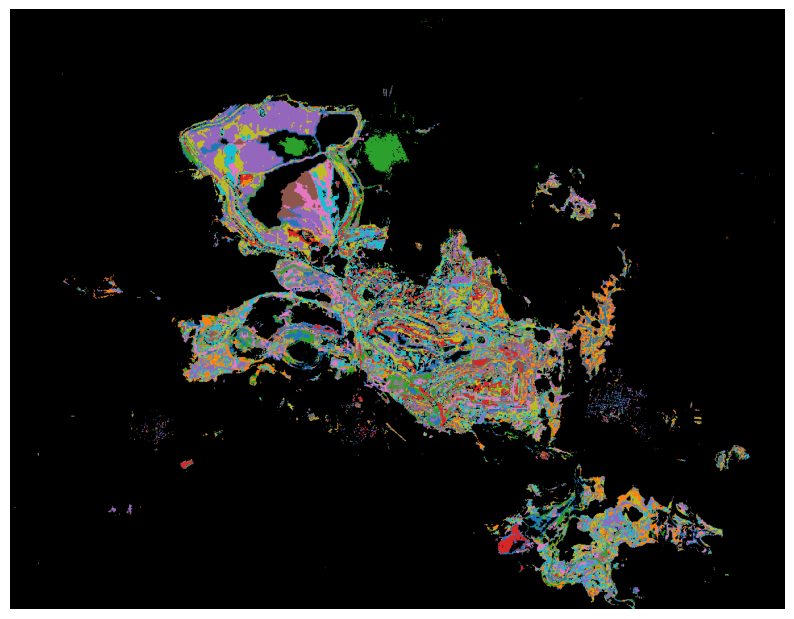

In [18]:
display_clusters(soil_mask_2d, labels_soil, optimal_k_soil)

<div id="23"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
2.3 Other

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We compute the 1D and 2D masks for the rest.

In [19]:
other_mask_2d = (soil_only[:, :, 0] == 0) & (vegetation_only[:,:,0]== 0)  # prendre la première bande uniquement
other_mask_1d = other_mask_2d.reshape(-1)         # pour filtrer les pixels

pixels = arr_img.reshape(-1, l)               # (m*n, l)
other_pixels = pixels[other_mask_1d]             

scaler = StandardScaler()
X_scaled_other = scaler.fit_transform(other_pixels)

img_scaled_other_complete = pixels.copy()
img_scaled_other_complete[other_mask_1d] = X_scaled_other
img_scaled_other_complete[~other_mask_1d] = np.mean(X_scaled_other)

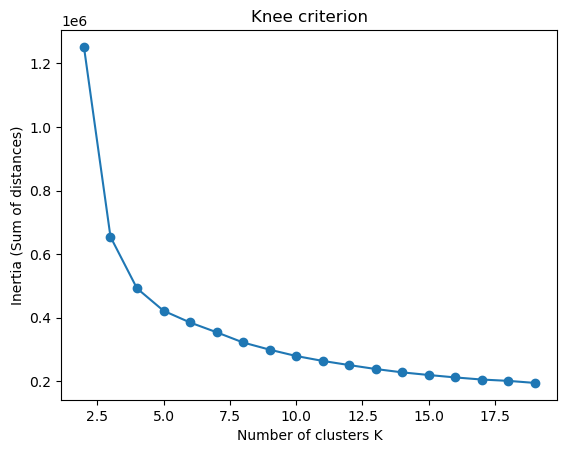

optimal value: k = 5


In [20]:
optimal_k_other = compute_optimal_k(X_scaled_other)

Silhouette (sampled) for k = 5 : 0.312
Calinski-Harabasz for k = 5 : 266786.01


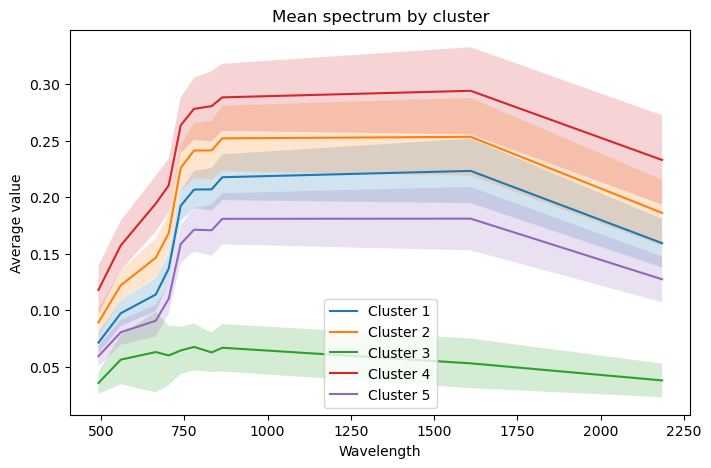

In [21]:
labels_other = KMeans_mean_spectra(X_scaled_other, other_mask_1d, optimal_k_other, l)

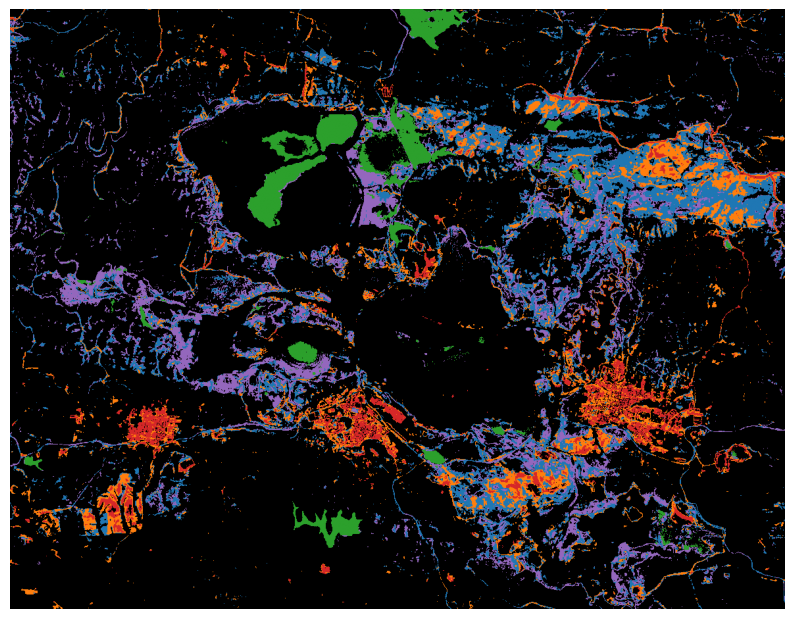

In [22]:
display_clusters(other_mask_2d, labels_other, optimal_k_other)

<div id="30"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    3. Pixel-by-Pixel AutoEncoder with K-Means on latent-space

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
We first try an AutoEncoder which takes separately each pixel and gives a latent representation. We then apply the K-means algorithm on these representations with the values of "optimal K" obtained precedently.

In [23]:
class PbPAutoencoder(nn.Module):
    def __init__(self, in_dim, latent_dim, dropout_rate=0.2):
        super().__init__()

        # Hyperparamètres
        self.latent_dim = latent_dim
        self.dropout_rate = dropout_rate

        # ----- Encodeur -----
        self.encoder = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Dropout(self.dropout_rate), # Régularisation
            
            # 2. Deuxième couche : Compression intermédiaire
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(self.dropout_rate), # Régularisation
            
            # 3. Troisième couche (Couche latente)
            nn.Linear(256, latent_dim)
        )

        # ----- Décodeur -----
        self.decoder = nn.Sequential(
            # 1. Premiére couche : Décompression intermédiaire
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            
            # 2. Deuxième couche : Décompression avancée
            nn.Linear(256, 512),
            nn.ReLU(),
            
            # 3. Dernière couche : Reconstruction de l'entrée
            nn.Linear(512, in_dim),
            nn.Sigmoid() # Pour s'assurer que les pixels sont entre 0 et 1
        )

    def forward(self, x):
        z = self.encoder(x)
        x_rec = self.decoder(z)
        return x_rec, z

In [24]:
def encode_all(model, dataloader, device):
    model.eval()
    latents = []

    with torch.no_grad():
        for x, in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

In [25]:
def train_PbP_autoencoder(LATENT_DIM, EPOCHS, X_scaled, n_clusters, max_samples=10000):

    # ------------------------------------------------------------------
    # Données simulées (remplace par tes vraies données)
    # ------------------------------------------------------------------
    H, W = m, n             # taille image
    BANDS = l                    # nb de bandes spectrales
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
    dataset = TensorDataset(X_tensor.T.reshape(l, -1).T)
    loader = DataLoader(dataset, batch_size=256, shuffle=True)
    loader_ordered = DataLoader(dataset, batch_size=256, shuffle=False)

    # ------------------------------------------------------------------
    # Autoencodeur
    # ------------------------------------------------------------------
    model = PbPAutoencoder(BANDS, LATENT_DIM).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Entraînement
    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0
        for x, in loader:
            x = x.to(DEVICE)

            out, _ = model(x)
            loss = criterion(out, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()

        print(f"Epoch {ep+1}/{EPOCHS}   Loss = {loss_sum/len(loader):.6f}")

    # ------------------------------------------------------------------
    # Extraction du latent
    # ------------------------------------------------------------------
    latent_vectors = encode_all(model, loader_ordered, DEVICE)   # shape = (H*W, LATENT_DIM)

    # ------------------------------------------------------------------
    # K-means
    # ------------------------------------------------------------------
    kmeans = KMeans(n_clusters, n_init=5, random_state=0)
    labels_1d = kmeans.fit_predict(latent_vectors)

    n_samples = X_scaled.shape[0]

    if n_samples > max_samples:
        idx = np.random.choice(n_samples, max_samples, replace=False)
        X_sampled = X_scaled[idx]
        labels_sampled = labels_1d[idx]
    else:
        X_sampled = X_scaled
        labels_sampled = labels_1d

    sil_score = silhouette_score(X_sampled, labels_sampled)
    ch_score  = calinski_harabasz_score(X_sampled, labels_sampled)

    print(f"Silhouette (échantillon) pour k = {n_clusters} : {sil_score:.3f}")
    print(f"Calinski-Harabasz pour k = {n_clusters} : {ch_score:.2f}")

    return labels_1d

In [26]:
def get_n_colors(n):
    base = plt.cm.get_cmap("tab20")   # ou "nipy_spectral", "viridis", etc.
    colors = base(np.linspace(0, 1, n))
    return colors.ListedColormap(colors)

<div id="31"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.1 Vegetation (and partial ARI)

In [27]:
labels_1d_veg = train_PbP_autoencoder(4, 5, X_scaled_veg, optimal_k_veg)

Epoch 1/5   Loss = 0.530197
Epoch 2/5   Loss = 0.525310
Epoch 3/5   Loss = 0.524971
Epoch 4/5   Loss = 0.524753
Epoch 5/5   Loss = 0.524657
Silhouette (échantillon) pour k = 5 : 0.291
Calinski-Harabasz pour k = 5 : 6648.87


In [28]:
X_cluster = np.zeros((m,n))
X_cluster[veg_mask_2d] = labels_veg

# 4. Extraction des résultats de clustering pour les pixels valides
# On applique le même masque au résultat du clustering
cluster_labels_for_comparison = X_cluster[valid_pixels_mask]

# Calcul de l'Adjusted Rand Index
ari_score = adjusted_rand_score(
    labels_true=ground_truth_labels, 
    labels_pred=cluster_labels_for_comparison
)

print(f"The partial Adjusted Rand Index (ARI) on vegetation with PbP Autoencoder + K-means on latent space is : {ari_score:.4f}")

The partial Adjusted Rand Index (ARI) on vegetation with PbP Autoencoder + K-means on latent space is : 0.5077


<div id="32"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.2 Soil

In [29]:
train_PbP_autoencoder(4, 5, X_scaled_soil, optimal_k_soil)

Epoch 1/5   Loss = 0.594006
Epoch 2/5   Loss = 0.582886
Epoch 3/5   Loss = 0.582572
Epoch 4/5   Loss = 0.582413
Epoch 5/5   Loss = 0.582087
Silhouette (échantillon) pour k = 30 : 0.161
Calinski-Harabasz pour k = 30 : 4026.22


array([ 3,  3,  3, ..., 27,  1,  7], dtype=int32)

<div id="33"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
3.3 Other

In [30]:
train_PbP_autoencoder(4, 5, X_scaled_other, optimal_k_other)

Epoch 1/5   Loss = 0.633275
Epoch 2/5   Loss = 0.624277
Epoch 3/5   Loss = 0.623816
Epoch 4/5   Loss = 0.623588
Epoch 5/5   Loss = 0.623399
Silhouette (échantillon) pour k = 5 : 0.303
Calinski-Harabasz pour k = 5 : 8958.27


array([2, 1, 2, ..., 2, 2, 2], dtype=int32)

<div id="40"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    4. 2D Convolutional AutoEncoder with K-Means on latent space

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
As our non-Convolutional AE provides poor results, we will now focus on Convolutional Autoencoders. We apply the K-means algorithm on the latent representation of patches (16*16 pixels for instance). To "propagate" the classification information, there are different options. 

In [67]:
LATENT_DIM = 4
EPOCHS = 5
PATCH_SIZE = 16
STRIDE = 1
BATCH_SIZE = 256
MAX_SAMPLES = 10000

In [68]:
class ConvAutoencoder(nn.Module):
    def __init__(self, in_channels=3, latent_dim=LATENT_DIM):
        """
        in_channels : nombre de canaux de l'image
        latent_dim  : taille du vecteur latent
        input_size  : taille de l'image d'entrée (supposé carré)
        """
        super(ConvAutoencoder, self).__init__()

        # ------- ENCODER -------
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, 3, stride=1, padding=1),  # H/2
            nn.ReLU(True),

            nn.Conv2d(32, 64, 3, stride=1, padding=1),           # H/4
            nn.ReLU(True),

            nn.Conv2d(64, 128, 3, stride=1, padding=1),          # H/8
            nn.ReLU(True)
        )
        
        # Pas besoin de input_size fixe : taille après conv dépend du patch
        self.fc_enc = None  # on initialisera dynamiquement au premier forward
        self.fc_dec = None

        # ------- DECODER -------
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride= 1, padding=1),  # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(64, 32, 3, stride=1, padding=1),   # H*2
            nn.ReLU(True),

            nn.ConvTranspose2d(32, in_channels, 3,stride= 1, padding=1),    # H*2
            nn.Sigmoid()
        )

        self.latent_dim = latent_dim
        self._fc_initialized = False

    def _init_fc(self, x):
        # Calculer la taille de flatten après encoder pour ce patch
        with torch.no_grad():
            z = self.encoder_conv(x)
            batch_size, c, h, w = z.size()
            
            # --- CORRECTION ICI ---
            # On crée la couche ET on l'envoie immédiatement sur le device de x (le GPU)
            self.fc_enc = nn.Linear(c*h*w, self.latent_dim).to(x.device)
            self.fc_dec = nn.Linear(self.latent_dim, c*h*w).to(x.device)
            # ----------------------
            
        self._fc_initialized = True

    def forward(self, x):
        if not self._fc_initialized:
            self._init_fc(x)
        # Encoder
        z = self.encoder_conv(x)
        batch_size, c, h, w = z.size()
        z_flat = z.view(batch_size, -1)        # Flatten
        z_latent = self.fc_enc(z_flat)                # Latent vector

        # Decoder
        z_dec = self.fc_dec(z_latent)
        z_dec = z_dec.view(batch_size, c, h, w)  # reshape exactement aux dimensions du conv
        x_recon = self.decoder_conv(z_dec)
        return x_recon, z_latent
    
    def encode(self, x):
        latent_map = self.encoder_conv(x)
        latent = latent_map.view(latent_map.size(0), -1)
        return latent

In [69]:
def extract_valid_patches_with_mask(image, mask, patch_size=PATCH_SIZE, stride=STRIDE, min_fraction=0.8):
    """
    Extrait des patchs valides selon un masque.
    
    image : [C,H,W]
    mask  : [H,W] ou [1,H,W], bool ou 0/1
    """
    if mask.dim() == 3:
        mask = mask[0]  # si mask [1,H,W]
    
    C, H, W = image.shape
    patches = []
    positions = []

    for i in range(0, H-patch_size+1, stride):
        for j in range(0, W-patch_size+1, stride):
            patch_mask = mask[i:i+patch_size, j:j+patch_size].bool()
            valid_fraction = patch_mask.float().mean().item()
            if valid_fraction >= min_fraction:
                num_valid_pixels = patch_mask.sum()
                patch = image[:, i:i+patch_size, j:j+patch_size]
                extended_mask = patch_mask.unsqueeze(0).expand_as(patch)
                valid_pixels = patch[extended_mask]
                valid_pixels = valid_pixels.view(C, -1)
                sum_valid_per_channel = valid_pixels.sum(dim=1)
                mean_valid_per_channel = sum_valid_per_channel / num_valid_pixels
                invalid_mask = ~extended_mask
                for c in range(C):
                    patch[c][invalid_mask[c]] = mean_valid_per_channel[c]
                patches.append(patch.unsqueeze(0))
                positions.append((i,j))
    
    if len(patches) > 0:
        patch_tensor = torch.cat(patches, dim=0)
    else:
        patch_tensor = torch.empty(0, C, patch_size, patch_size)
    
    return patch_tensor, positions

In [70]:
def train_Conv2D_autoencoder(LATENT_DIM, EPOCHS, X_scaled, n_clusters, PATCH_SIZE, STRIDE, BATCH_SIZE, img_scaled_complete, mask_2d, MAX_SAMPLES):

    # --- Configuration ---
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Utilization du device : {DEVICE}")

    # --- Initialisation du Modèle ---
    model = ConvAutoencoder(in_channels=l).to(DEVICE)
    
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    patch_tensor, positions = extract_valid_patches_with_mask(torch.Tensor(img_scaled_complete.T.reshape(l,m,n)), torch.Tensor(mask_2d), PATCH_SIZE, STRIDE)
    print(f"Nombre de patchs valides : {len(patch_tensor)}")
    
    dataset = TensorDataset(patch_tensor)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    # Paramètres boucle
    total_idx = []
    n_batches = 10
    all_latents = []

    for ep in range(EPOCHS):
        model.train()
        loss_sum = 0

        # Échantillonnage aléatoire
        dataset_size = len(dataset)
        n_samples = min(n_batches * BATCH_SIZE, dataset_size)
        idx = np.random.choice(dataset_size, n_samples, replace=False)
        total_idx.extend(idx)
        
        subset_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
        batch_idx = 0
        for batch in loader:
            batch_idx += 1
            x = batch[0].to(DEVICE)
            optimizer.zero_grad()
            out, _ = model(x)
            loss = criterion(out, x)
            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            print(f"\rEpoch {ep+1}/{EPOCHS}  Batch {batch_idx+1}/{len(subset_loader)}  Loss: {loss.item():.6f}", end="")
            sys.stdout.flush()

        
        print(f"\nEpoch {ep+1}/{EPOCHS}   Moyenne Loss = {loss_sum/len(subset_loader):.6f}")

    # ----------------------
    # Extraction des latents
    # ----------------------
    model.eval()
    all_latents = []
    with torch.no_grad():
        for batch in DataLoader(patch_tensor, batch_size=BATCH_SIZE, shuffle=False):
            x = batch[0].to(DEVICE)
            latent = model.encode(x)
            all_latents.append(latent.cpu().numpy())
    latent_vectors = np.concatenate(all_latents, axis=0)

    return latent_vectors, positions

<div id="41"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.1 Vegetation (and ARI)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
A simple option is to assume the cluster assigned to the patch is in reality the cluster assigned to the pixel at the center of this patch.

In [71]:
class PatchDataset(Dataset):
    def __init__(self, cube, patch_size):
        """
        cube        : tensor [bands, H, W]
        patch_size  : int
        """
        self.cube = cube
        self.patch = patch_size
        self.pad = patch_size // 2

        # padding pour ne pas perdre les bords
        self.cube_pad = F.pad(cube, (self.pad, self.pad, self.pad, self.pad))

        self.H, self.W = cube.shape[1], cube.shape[2]

    def __len__(self):
        return self.H * self.W

    def __getitem__(self, idx):
        h = idx // self.W
        w = idx % self.W

        patch = self.cube_pad[:, 
                              h : h + 2*self.pad + 1,
                              w : w + 2*self.pad + 1]

        return patch   # shape = [bands, patch, patch]

In [72]:
def encode_all(model, dataloader, device):
    model.eval()
    latents = []

    with torch.no_grad():
        for x in dataloader:
            x = x.to(device)
            _, z = model(x)
            latents.append(z.cpu().numpy())

    return np.concatenate(latents, axis=0)

In [73]:
def KM_Silhouette(latent_vectors, n_clusters):
    kmeans = KMeans(n_clusters, n_init=5, random_state=0)
    labels = kmeans.fit_predict(latent_vectors)
    sample = random.sample(range(latent_vectors.shape[0]), 10000)
    latent_vectors_sampled = latent_vectors[sample, :]
    labels_sampled = labels[sample]
    
    sil_score = silhouette_score(latent_vectors_sampled, labels_sampled)
    print(f"Silhouette (on a subset) for k = {n_clusters} : {sil_score:.3f}")
    ch_score  = calinski_harabasz_score(latent_vectors_sampled, labels_sampled)
    print(f"Calinski-Harabasz for k = {n_clusters} : {ch_score:.2f}")

    return labels

In [74]:
latent_vectors_veg, positions = train_Conv2D_autoencoder(
    LATENT_DIM, EPOCHS, X_scaled_veg, optimal_k_veg, 
    PATCH_SIZE, STRIDE, BATCH_SIZE, 
    img_scaled_veg_complete, veg_mask_2d, MAX_SAMPLES
)

Utilization du device : cuda
Nombre de patchs valides : 533759
Epoch 1/5  Batch 2086/2085  Loss: 0.623292
Epoch 1/5   Moyenne Loss = 0.624358
Epoch 2/5  Batch 2086/2085  Loss: 0.571779
Epoch 2/5   Moyenne Loss = 0.611226
Epoch 3/5  Batch 2086/2085  Loss: 0.583004
Epoch 3/5   Moyenne Loss = 0.609416
Epoch 4/5  Batch 2086/2085  Loss: 0.601762
Epoch 4/5   Moyenne Loss = 0.608251
Epoch 5/5  Batch 2086/2085  Loss: 0.632069
Epoch 5/5   Moyenne Loss = 0.607350


In [75]:
labels_veg = KM_Silhouette(latent_vectors_veg, optimal_k_veg)

Silhouette (on a subset) for k = 5 : 0.462
Calinski-Harabasz for k = 5 : 8141.35


In [ ]:
# Nombre de patches clustérisés (taille N)
N_patches = len(labels_veg)
# Décalage pour trouver le pixel central du patch
center_offset = PATCH_SIZE // 2

# --- 2. Création de la Vraie Étiquette ALIGNÉE (y_true_reordered) ---

# Créer un tableau de taille N_patches, initialisé à 0
y_true_reordered = np.zeros(N_patches, dtype=np.int32) 

# Parcourir chaque patch dans l'ordre de 'positions' (et donc de 'labels_veg')
for i, (r_start, c_start) in enumerate(positions):
    r_center = r_start + center_offset
    c_center = c_start + center_offset
    
    # Récupérer l'étiquette GT du pixel central du patch
    # Les valeurs de 0 (non étiqueté) ou > 0 (classe) sont stockées
    if r_center < m and c_center < n:
        y_true_reordered[i] = ground_truth_array[r_center, c_center]

# --- 3. Filtrage Simultané pour l'ARI ---

# 3a. Créer le masque de filtrage : True là où l'étiquette GT est connue (GT > 0)
mask_labeled = (y_true_reordered > 0) 

# 3b. Application du masque : y_true_final et y_pred_final ont la même taille M
labels_true_final = y_true_reordered[mask_labeled] # Vraies étiquettes filtrées
labels_pred_final = labels_veg[mask_labeled]      # Prédictions filtrées (alignées)

# --- 4. Calcul de l'Adjusted Rand Index CORRIGÉ ---

if len(labels_true_final) > 0:
    ari_score_corrected = adjusted_rand_score(
        labels_true=labels_true_final, 
        labels_pred=labels_pred_final
    )
    print("-" * 70)
    print(f"✅ Adjusted Rand Index (ARI) CORRIGÉ sur {len(labels_true_final)} échantillons : {ari_score_corrected:.4f}")
    print("-" * 70)
else:
    print("❌ ERREUR D'ÉVALUATION : Aucun patch extrait ne correspond à un pixel étiqueté dans la vérité terrain.")

In [80]:
ground_truth_labels_image = np.full((m, n), -1)
ground_truth_labels_image[valid_pixels_mask] = ground_truth_labels

X_cluster = np.full((m, n), -1)
for (i, j), label in zip(positions, labels_veg):
    end_i = min(i + PATCH_SIZE, m)
    end_j = min(j + PATCH_SIZE, n)
    X_cluster[i:end_i, j:end_j] = label
comparison_mask = (ground_truth_labels_image != -1) & (X_cluster != -1)

if comparison_mask.sum() > 0:
    y_true_final = ground_truth_labels_image[comparison_mask]
    y_pred_final = X_cluster[comparison_mask]

    ari_score = adjusted_rand_score(y_true_final, y_pred_final)
    print(f"Partial Adjusted Rand Index (ARI): {ari_score:.4f}")
    print(f"Calculé sur {comparison_mask.sum()} pixels communs.")
else:
    print("Erreur : Aucun recouvrement entre les patchs prédits et la vérité terrain.")

Partial Adjusted Rand Index (ARI): 0.0010
Calculé sur 20202 pixels communs.


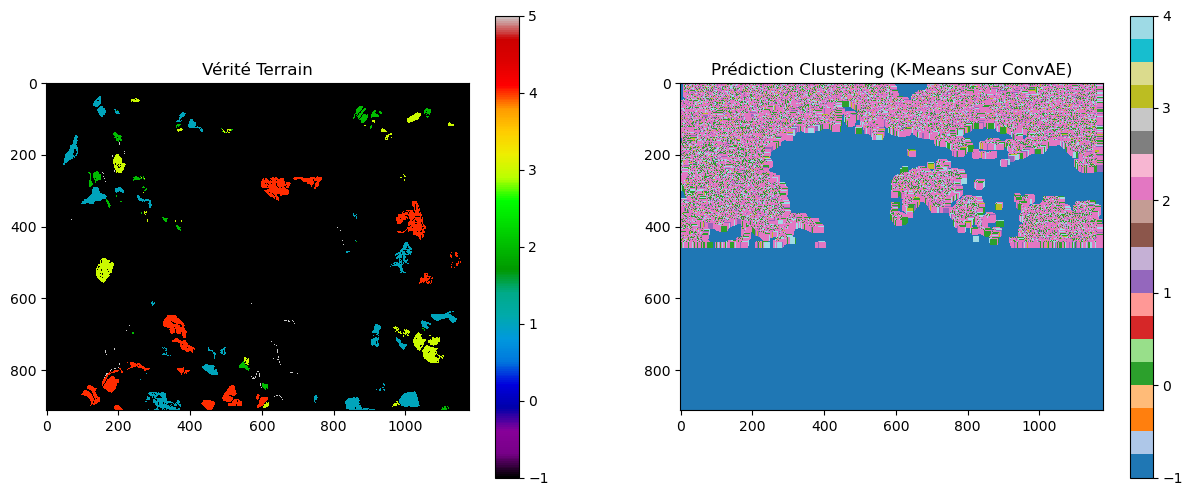

In [82]:
plt.figure(figsize=(15, 6))

# 1. Vérité Terrain
plt.subplot(1, 2, 1)
plt.imshow(ground_truth_labels_image, cmap='nipy_spectral', interpolation='nearest')
plt.title("Vérité Terrain")
plt.colorbar()

display_cluster = X_cluster.copy()

plt.subplot(1, 2, 2)
plt.imshow(display_cluster, cmap='tab20', interpolation='nearest')
plt.title("Prédiction Clustering (K-Means sur ConvAE)")
plt.colorbar()

plt.show()

In [66]:
X_cluster = np.zeros((m,n))
X_cluster[veg_mask_2d] = labels_veg

# 4. Extraction des résultats de clustering pour les pixels valides
# On applique le même masque au résultat du clustering
cluster_labels_for_comparison = X_cluster[valid_pixels_mask]

# Calcul de l'Adjusted Rand Index
ari_score = adjusted_rand_score(
    labels_true=ground_truth_labels, 
    labels_pred=cluster_labels_for_comparison
)

print(f"The partial Adjusted Rand Index (ARI) on vegetation with Direct K-means is : {ari_score:.4f}")

ValueError: NumPy boolean array indexing assignment cannot assign 266880 input values to the 668215 output values where the mask is true

<div id="42"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.2 Soil

In [55]:
latent_vectors_soil = train_Conv2D_autoencoder(LATENT_DIM, EPOCHS, X_scaled_soil, optimal_k_soil, PATCH_SIZE, STRIDE, BATCH_SIZE, img_scaled_soil_complete, soil_mask_2d, MAX_SAMPLES)

Utilization du device : cuda
Nombre de patchs valides : 126033
Epoch 1/5  Batch 494/493  Loss: 0.649873
Epoch 1/5   Moyenne Loss = 0.631313
Epoch 2/5  Batch 494/493  Loss: 0.518741
Epoch 2/5   Moyenne Loss = 0.587709
Epoch 3/5  Batch 494/493  Loss: 0.667112
Epoch 3/5   Moyenne Loss = 0.583242
Epoch 4/5  Batch 494/493  Loss: 0.608564
Epoch 4/5   Moyenne Loss = 0.580693
Epoch 5/5  Batch 494/493  Loss: 0.582147
Epoch 5/5   Moyenne Loss = 0.579146


In [56]:
labels_soil = KM_Silhouette(latent_vectors_soil, optimal_k_soil)

Silhouette (on a subset) for k = 30 : 0.345
Calinski-Harabasz for k = 30 : 1726.25


<div id="43"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.3 Other

In [57]:
latent_vectors_other = train_Conv2D_autoencoder(LATENT_DIM, EPOCHS, X_scaled_other, optimal_k_other, PATCH_SIZE, STRIDE, BATCH_SIZE, img_scaled_other_complete, other_mask_2d, MAX_SAMPLES)

Utilization du device : cuda
Nombre de patchs valides : 71944
Epoch 1/5  Batch 283/282  Loss: 0.293091
Epoch 1/5   Moyenne Loss = 0.927624
Epoch 2/5  Batch 283/282  Loss: 1.504592
Epoch 2/5   Moyenne Loss = 0.877651
Epoch 3/5  Batch 283/282  Loss: 2.135895
Epoch 3/5   Moyenne Loss = 0.877678
Epoch 4/5  Batch 283/282  Loss: 0.822843
Epoch 4/5   Moyenne Loss = 0.871903
Epoch 5/5  Batch 283/282  Loss: 0.178842
Epoch 5/5   Moyenne Loss = 0.868886


In [58]:
labels_other = KM_Silhouette(latent_vectors_other, optimal_k_other)

Silhouette (on a subset) for k = 5 : 0.600
Calinski-Harabasz for k = 5 : 13575.21


<div id="44"></div>
<div style="background-color: #FAE5D3; border-left: 10px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 24px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 600;">
4.4 Nombre de clusters pour la végétation avec CAH

In [46]:
N = 20000
idx = np.random.choice(len(X_scaled_veg), N, replace=False)
X_sample = X_scaled_veg[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

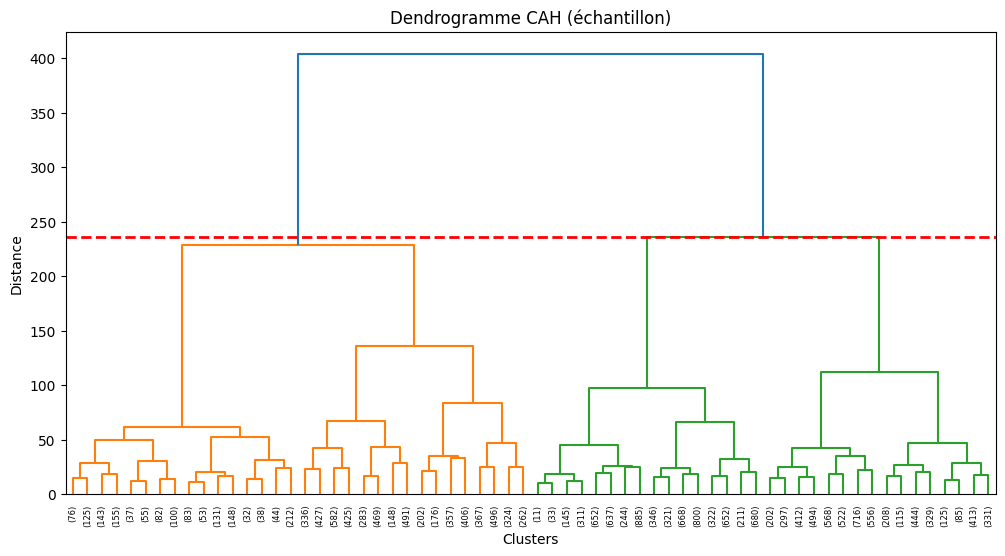

In [47]:
plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()

In [48]:
X_sample = X_scaled_other

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()


MemoryError: Unable to allocate 204. GiB for an array with shape (27427981791,) and data type float64

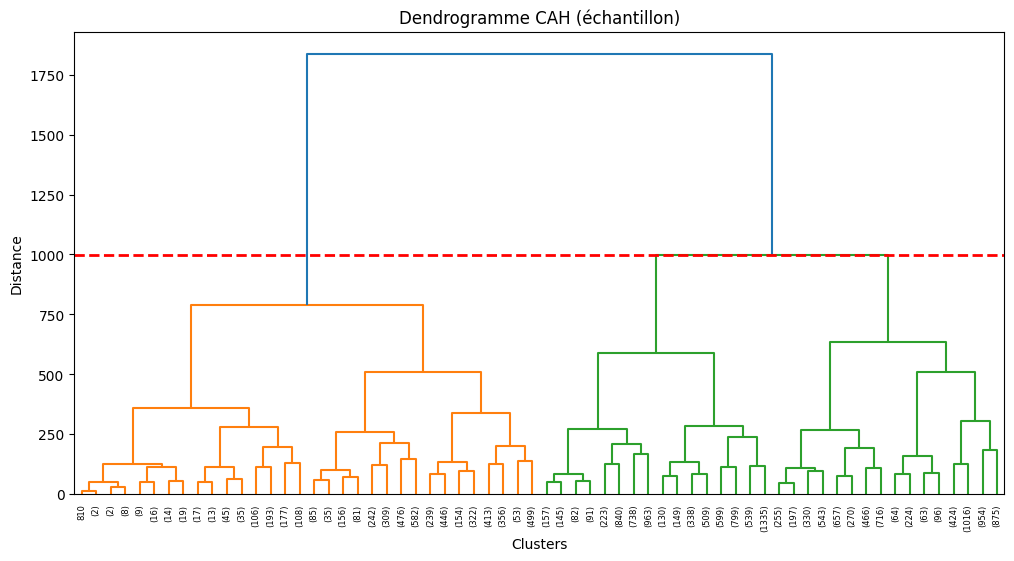

In [ ]:
N = 20000
idx = np.random.choice(len(X_scaled_soil), N, replace=False)
X_sample = X_scaled_soil[idx]

Z = linkage(X_sample, method='ward')

# distances entre fusions successives
distances = Z[:, 2]

# trouve le plus grand saut
jumps = np.diff(distances)
threshold = distances[np.argmax(jumps)]

labels = fcluster(Z, t=threshold, criterion='distance')

plt.figure(figsize=(12, 6))
dendrogram(Z, truncate_mode='level', p=5)  # p = profondeur affichée
# Ligne horizontale correspondant au seuil trouvé automatiquement
plt.axhline(y=threshold, color='red', linewidth=2, linestyle='--')
plt.title("Dendrogramme CAH (échantillon)")
plt.xlabel("Clusters")
plt.ylabel("Distance")
plt.show()